# SpaOT tutorial

This notebook walks through a small synthetic alignment problem using SpaOT/FPGW.
The goal is to make every input and output matrix explicit:

- `X_src`: source node features, shape `(n, d)`
- `X_tgt`: target node features, shape `(m, d)`
- `M`: cross-sample feature cost matrix, shape `(n, m)`
- `C_src`: source within-sample structure matrix, shape `(n, n)`
- `C_tgt`: target within-sample structure matrix, shape `(m, m)`
- `p`, `q`: source and target masses, shapes `(n,)` and `(m,)`
- `G`: transport plan, shape `(n, m)`
- `cost`: scalar objective value for a fixed transport plan

SpaOT uses Fused Partial Gromov-Wasserstein optimal transport. It combines a **feature term** and a **structure term**, while allowing some mass to remain unmatched when source and target sizes or compositions differ.

In [1]:
from pathlib import Path
import os
import sys

# Make the notebook runnable from either the repository root or the SpaOT folder.
cwd = Path.cwd()
if (cwd / "lib").exists():
    spaot_root = cwd
elif (cwd / "SpaOT" / "lib").exists():
    spaot_root = cwd / "SpaOT"
else:
    raise RuntimeError("Run this notebook from the repository root or from the SpaOT/ folder.")

os.chdir(spaot_root)
if str(spaot_root) not in sys.path:
    sys.path.insert(0, str(spaot_root))

import numpy as np
import matplotlib.pyplot as plt

from lib.fused_pgw import fused_partial_gromov_wasserstein, fused_pgw_cost

np.set_printoptions(precision=3, suppress=True)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/shuangwang/Downloads/spaOT 2


## 1. Create a moon source and target problem

Each row in `X_src` or `X_tgt` is a node feature vector. Here the feature is the original moon class label from the synthetic benchmark used in `reproductivity/simulatoin benchmark/fig2ac_spaOT_object_mapping.py`.

The `coord_src` and `coord_tgt` arrays are the two-dimensional moon coordinates used to build the structure matrices. The target includes uniformly scattered outlier nodes, so partial matching is useful.


In [2]:
from sklearn.datasets import make_moons


def normalize_matrix(A):
    """Scale a matrix to [0, 1], leaving all-zero matrices unchanged."""
    A = np.asarray(A, dtype=float)
    amin, amax = A.min(), A.max()
    if np.isclose(amax, amin):
        return np.zeros_like(A)
    return (A - amin) / (amax - amin)


def pairwise_sqeuclidean(A, B):
    """Return squared Euclidean distances between rows of A and rows of B."""
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    return ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)


def pairwise_euclidean(A, B):
    return np.sqrt(pairwise_sqeuclidean(A, B))


def rotation_2d(theta=0):
    return np.array(
        [
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)],
        ]
    )


In [3]:
#load the dataset
data = np.load("graph_data.npz")

label_src = data["label_src"]
label_tgt = data["label_tgt"]
coord_src = data["coord_src"]
coord_tgt = data["coord_tgt"]

# Create the feature matrix from the labels
X_src = label_src[:, None].astype(float)
X_tgt = label_tgt[:, None].astype(float)

print("Feature shapes")
print(f"X_src: {X_src.shape}  # n source nodes by d features")
print(f"X_tgt: {X_tgt.shape}  # m target nodes by d features")
print("Coordinate shapes")
print(f"coord_src: {coord_src.shape}")
print(f"coord_tgt: {coord_tgt.shape}  # includes {len(X_tgt) - len(X_src)} target outliers")

Feature shapes
X_src: (400, 1)  # n source nodes by d features
X_tgt: (440, 1)  # m target nodes by d features
Coordinate shapes
coord_src: (400, 2)
coord_tgt: (440, 2)  # includes 40 target outliers


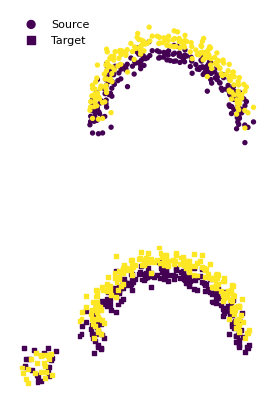

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(coord_src[:, 0], coord_src[:, 1],
           c=label_src, s=8, label="Source")

ax.scatter(coord_tgt[:, 0], coord_tgt[:, 1],
           c=label_tgt, s=8, marker="s", label="Target")

ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.legend(frameon=False, loc="upper left", fontsize=8, markerscale=2)

plt.tight_layout(pad=0.3)
plt.show()

## 2. Build the matrices SpaOT needs

SpaOT needs one cross-sample feature cost matrix and two within-sample structure matrices.

- `M[i, j]` is the feature mismatch between source node `i` and target node `j`. In this demo it is computed from the moon class label feature.
- `C_src[i, k]` is the spatial distance between source moon nodes `i` and `k`.
- `C_tgt[j, l]` is the spatial distance between target moon nodes `j` and `l`.

All three matrices are normalized to `[0, 1]` here. This matters because the SpaOT objective combines feature and structure terms; badly scaled matrices can make one term dominate.


In [5]:
M = normalize_matrix(pairwise_sqeuclidean(X_src, X_tgt))
C_src = (pairwise_euclidean(coord_src, coord_src))
C_tgt = (pairwise_euclidean(coord_tgt, coord_tgt))

# Uniform masses. We divide by max(n, m) so total source and target masses can be
# less than or equal to 1 and partial matching can leave unmatched mass.
n, m = X_src.shape[0], X_tgt.shape[0]
p = np.ones(n) / max(n, m)
q = np.ones(m) / max(n, m)

print("Matrix and vector dimensions")
print(f"M:     {M.shape}  # source-by-target feature cost")
print(f"C_src: {C_src.shape}  # source-by-source structure")
print(f"C_tgt: {C_tgt.shape}  # target-by-target structure")
print(f"p:     {p.shape}, total mass={p.sum():.3f}")
print(f"q:     {q.shape}, total mass={q.sum():.3f}")

Matrix and vector dimensions
M:     (400, 440)  # source-by-target feature cost
C_src: (400, 400)  # source-by-source structure
C_tgt: (440, 440)  # target-by-target structure
p:     (400,), total mass=0.909
q:     (440,), total mass=1.000


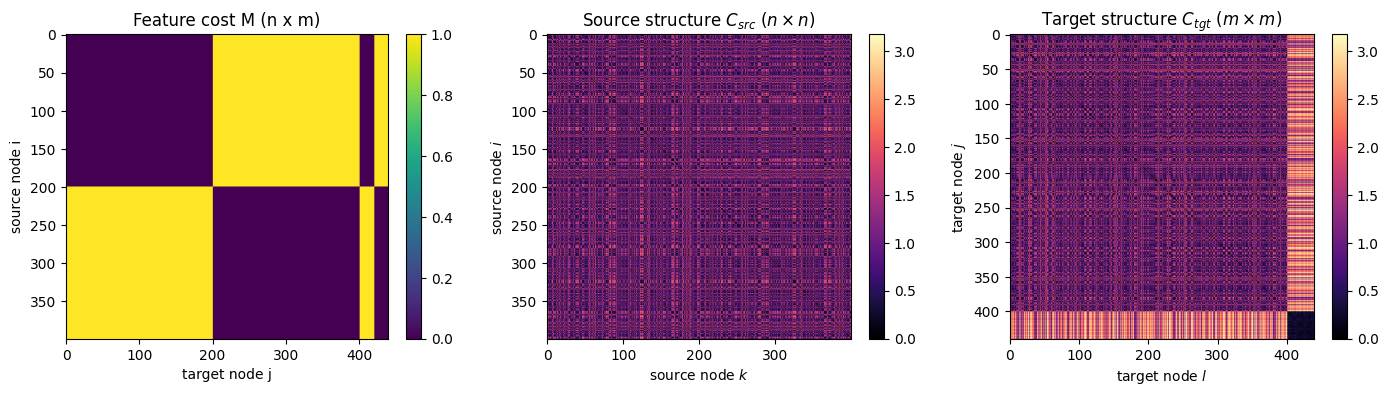

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(M, cmap="viridis", aspect="auto")
axes[0].set_title("Feature cost M (n x m)")
axes[0].set_xlabel("target node j")
axes[0].set_ylabel("source node i")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

vmin = min(C_src.min(), C_tgt.min())
vmax = max(C_src.max(), C_tgt.max())

im1 = axes[1].imshow(C_src, cmap="magma", vmin=vmin, vmax=vmax)
axes[1].set_title("Source structure $C_{src}$ ($n\\times n$)")
axes[1].set_xlabel("source node $k$")
axes[1].set_ylabel("source node $i$")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(C_tgt, cmap="magma", vmin=vmin, vmax=vmax)
axes[2].set_title("Target structure $C_{tgt}$ ($m\\times m$)")
axes[2].set_xlabel("target node $l$")
axes[2].set_ylabel("target node $j$")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 3. Run SpaOT/FPGW and inspect the transport plan

The transport plan `G` is an `(n, m)` matrix. Entry `G[i, j]` is the amount of mass transported from source node `i` to target node `j`.

The parameter `omega2` controls the tradeoff:

- `omega2 = 0.0`: feature-only partial OT
- `omega2 = 1.0`: structure-only partial GW
- `0 < omega2 < 1`: SpaOT/FPGW, using both feature and structure

`Lambda` penalizes unmatched mass. Larger values encourage transporting more mass; smaller values allow more mass to remain unmatched.

In [7]:
def run_spaot(omega2, label, Lambda=1.0):
    G = fused_partial_gromov_wasserstein(
        M,
        C_src,
        C_tgt,
        p=p,
        q=q,
        omega2=omega2,
        Lambda=Lambda
    )
    cost = fused_pgw_cost(M, C_src, C_tgt, G, omega2=omega2, loss_fun="square_loss")
    return {"label": label, "omega2": omega2, "G": G, "cost": cost}

result = run_spaot(0.5, "SpaOT/FPGW: features + structure")

G = result["G"]
print(result["label"])
print(f"  G shape: {G.shape}")
print(f"  transported mass: {G.sum():.3f}")
print(f"  source matched mass range: {G.sum(axis=1).min():.3f} to {G.sum(axis=1).max():.3f}")
print(f"  target matched mass range: {G.sum(axis=0).min():.3f} to {G.sum(axis=0).max():.3f}")
print(f"  transport cost: {result['cost']:.6f}\n")

SpaOT/FPGW: features + structure
  G shape: (400, 440)
  transported mass: 0.909
  source matched mass range: 0.002 to 0.002
  target matched mass range: 0.000 to 0.002
  transport cost: 0.001894



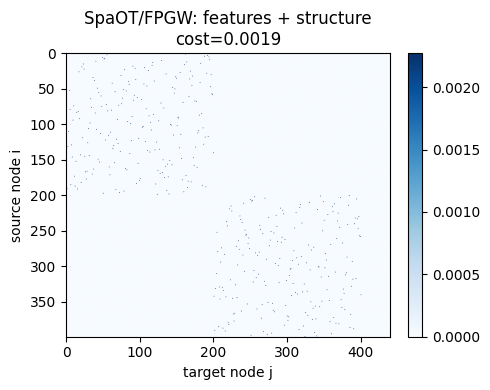

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(result["G"], cmap="Blues", aspect="auto")

ax.set_title(f"{result['label']}\ncost={result['cost']:.4f}")
ax.set_xlabel("target node j")
ax.set_ylabel("source node i")

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 4. Visualize object mappings in space

This plot follows the Figure 2a,c object-mapping visualization: source and target objects are colored by their original moon labels, the source coordinates are horizontally flipped when that gives the lower transported spatial cost, and every transported pair above a small threshold is drawn as a gray correspondence line.


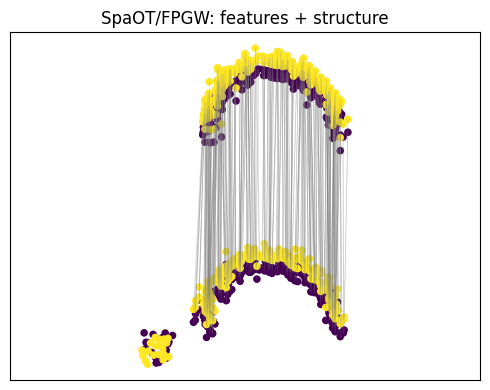

In [9]:
def plot_plan_2d(ax, X, Y, gamma, threshold=1e-8, X1_label=None, X2_label=None, title=None):
    # Auto-detect if X is mirrored relative to Y, matching the Figure 2 plotting helper.
    def transport_cost(Xa, Y, gamma):
        cost = 0.0
        for i in range(Xa.shape[0]):
            for j in range(Y.shape[0]):
                if gamma[i, j] > threshold:
                    dx = Xa[i, 0] - Y[j, 0]
                    dy = Xa[i, 1] - Y[j, 1]
                    cost += gamma[i, j] * (dx * dx + dy * dy)
        return cost

    cost_original = transport_cost(X, Y, gamma)

    X_flipped = X.copy()
    X_flipped[:, 0] = -X_flipped[:, 0]
    cost_flipped = transport_cost(X_flipped, Y, gamma)

    if cost_flipped < cost_original:
        X_used = X_flipped
    else:
        X_used = X

    ax.scatter(X_used[:, 0], X_used[:, 1], c=X1_label, s=20)
    ax.scatter(Y[:, 0], Y[:, 1], c=X2_label, s=20)

    for i in range(X_used.shape[0]):
        for j in range(Y.shape[0]):
            if gamma[i, j] > threshold:
                ax.plot(
                    [X_used[i, 0], Y[j, 0]],
                    [X_used[i, 1], Y[j, 1]],
                    "grey",
                    lw=gamma[i, j] * 150,
                    alpha=0.4,
                )

    ax.set_title(title)
    ax.axis("equal")
    ax.set_xticks([])
    ax.set_yticks([])


fig, ax = plt.subplots(figsize=(5, 4))

plot_plan_2d(
    ax,
    coord_src,
    coord_tgt,
    result["G"],
    X1_label=label_src,
    X2_label=label_tgt,
    title=result["label"],
)

plt.tight_layout()
plt.show()


## 5. What does the transport cost mean?

`fused_pgw_cost(M, C_src, C_tgt, G, omega2)` evaluates the SpaOT objective for the plan `G`.

Conceptually:

- the **feature term** is small when matched source-target nodes have similar features;
- the **structure term** is small when distances among matched source nodes resemble distances among matched target nodes;
- `omega2` controls how much the structure term contributes relative to the feature term.

The cost is most useful when comparing plans generated from the same normalized inputs and the same parameter settings. If you change normalization, `omega2`, `Lambda`, or preprocessing, the absolute value can change scale. In manuscript analyses, transport costs are used as sample-level distances after applying a consistent workflow across samples.

In [10]:

costs = result["cost"]
transported = [result["G"].sum()]

print(f"omega2={result['omega2']:.3f}, cost={costs:.6f}, transported mass={transported[0]:.3f}")

omega2=0.500, cost=0.001894, transported mass=0.909


In [ ]:
M = normalize_matrix(pairwise_sqeuclidean(X_src, X_tgt))
C_src = (pairwise_euclidean(coord_src, coord_src))
C_tgt = (pairwise_euclidean(coord_tgt, coord_tgt))


array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]])

In [12]:
import numpy as np

np.savez_compressed(
    "graph_data_input_matrices.npz",
    M=M,
    C1=C_src,
    C2=C_tgt)

print("Saved to graph_data_input_matrices.npz")

Saved to graph_data_input_matrices.npz
